In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight


# -----------------------------
# 1. CONFIG
# -----------------------------

DATA_ROOT = Path("/mnt/extssd/Earthworms/petridish-worm-images")  # change this
IMAGE_COL = "rel_path_seg"
MASK_COL = "rel_path_segmask"

TARGET_COL = "species_label"
GROUP_COL = "individual_id"

MIN_INDIVIDUALS_PER_CLASS = 20
RANDOM_STATE = 42

global_metadata = pd.read_csv(os.path.join(DATA_ROOT,'01_Segmented','global_metadata.csv'))


global_metadata['species'] = global_metadata['barcode'].str.replace(r'_\d+$', '', regex=True)
global_metadata['date'] = pd.to_datetime(global_metadata['timestamp']).apply(lambda x: x.date())

# 2. CLEAN METADATA
# -----------------------------

df = global_metadata.copy()

# Safer parsing: remove only Adult/Juvenile suffix
df[["taxon_label", "life_stage"]] = df["species"].str.extract(
    r"^(.+)_(Adult|Juvenile)$"
)

df["genus"] = df["taxon_label"].str.split("_").str[0]
df["species_label"] = df["taxon_label"]

# Individual ID:
# If barcode already means individual, keep it.
# If barcode sometimes has image replicate suffix, remove only the final suffix.
# Example: Aporrectodea_rosea_Adult_14_1 -> Aporrectodea_rosea_Adult_14
df["individual_id"] = df["barcode"].astype(str)


# Check this manually!
print(df[["barcode", "individual_id", "species", "species_label", "life_stage"]].head(10))

                                            barcode  \
0                       Aporrectodea_rosea_Adult_14   
1                       Aporrectodea_rosea_Adult_14   
2                       Aporrectodea_rosea_Adult_14   
3                       Aporrectodea_rosea_Adult_14   
4                       Aporrectodea_rosea_Adult_14   
5  Aporrectodea_caliginosa_tuberculata_Juvenile_161   
6  Aporrectodea_caliginosa_tuberculata_Juvenile_161   
7  Aporrectodea_caliginosa_tuberculata_Juvenile_161   
8  Aporrectodea_caliginosa_tuberculata_Juvenile_161   
9  Aporrectodea_caliginosa_tuberculata_Juvenile_161   

                                      individual_id  \
0                       Aporrectodea_rosea_Adult_14   
1                       Aporrectodea_rosea_Adult_14   
2                       Aporrectodea_rosea_Adult_14   
3                       Aporrectodea_rosea_Adult_14   
4                       Aporrectodea_rosea_Adult_14   
5  Aporrectodea_caliginosa_tuberculata_Juvenile_161   
6  Aporre

In [2]:
# -----------------------------
# 3. FILTER RARE CLASSES
# -----------------------------

individual_counts = df.groupby(TARGET_COL)[GROUP_COL].nunique()

valid_classes = individual_counts[
    individual_counts >= MIN_INDIVIDUALS_PER_CLASS
].index

df = df[df[TARGET_COL].isin(valid_classes)].reset_index(drop=True)

print("Classes retained:")
print(df.groupby(TARGET_COL)[GROUP_COL].nunique().sort_values(ascending=False))
print("Rows after filtering:", len(df))

Classes retained:
species_label
Aporrectodea_caliginosa_tuberculata    388
Allolobophora_chlorotica               176
Lumbricus_sp                           165
Aporrectodea_longa                     159
Aporrectodea_tuberculata               105
Aporrectodea_rosea                      53
Aporrectodea_caliginosa                 36
Name: individual_id, dtype: int64
Rows after filtering: 6039


In [3]:
# -----------------------------
# 4. FEATURE EXTRACTION
# -----------------------------

def safe_read_image(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def safe_read_mask(path):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    return (mask > 0).astype(np.uint8)


def extract_features(seg_path, mask_path=None):
    """
    Extract morphology, colour, and simple texture features from segmented worm image.
    Assumes background is black or uses the provided segmentation mask.
    """

    img = safe_read_image(seg_path)
    if img is None:
        return None

    h, w = img.shape[:2]

    if mask_path is not None and Path(mask_path).exists():
        mask = safe_read_mask(mask_path)
    else:
        # fallback: infer worm mask from non-black pixels
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = (gray > 5).astype(np.uint8)

    if mask is None or mask.sum() < 50:
        return None

    # keep largest connected component
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if num_labels <= 1:
        return None

    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mask = (labels == largest_label).astype(np.uint8)

    area = float(mask.sum())
    img_area = float(h * w)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None

    contour = max(contours, key=cv2.contourArea)

    perimeter = float(cv2.arcLength(contour, closed=True))
    contour_area = float(cv2.contourArea(contour))

    x, y, bw, bh = cv2.boundingRect(contour)
    bbox_area = float(bw * bh)

    extent = contour_area / bbox_area if bbox_area > 0 else np.nan

    hull = cv2.convexHull(contour)
    hull_area = float(cv2.contourArea(hull))
    solidity = contour_area / hull_area if hull_area > 0 else np.nan

    aspect_ratio = bw / bh if bh > 0 else np.nan

    circularity = (
        4 * np.pi * contour_area / (perimeter ** 2)
        if perimeter > 0 else np.nan
    )

    # Ellipse features
    if len(contour) >= 5:
        ellipse = cv2.fitEllipse(contour)
        (_, _), (major_axis, minor_axis), angle = ellipse

        major_axis = max(major_axis, minor_axis)
        minor_axis = min(major_axis, minor_axis)

        eccentricity = np.sqrt(
            1 - (minor_axis ** 2 / major_axis ** 2)
        ) if major_axis > 0 else np.nan
    else:
        major_axis = np.nan
        minor_axis = np.nan
        angle = np.nan
        eccentricity = np.nan

    # Hu moments: shape descriptors
    moments = cv2.moments(mask)
    hu = cv2.HuMoments(moments).flatten()
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)

    # Colour features inside worm mask
    pixels = img[mask.astype(bool)]

    colour_features = {}
    for i, channel in enumerate(["R", "G", "B"]):
        vals = pixels[:, i].astype(float)
        colour_features[f"{channel}_mean"] = np.mean(vals)
        colour_features[f"{channel}_std"] = np.std(vals)
        colour_features[f"{channel}_median"] = np.median(vals)
        colour_features[f"{channel}_q10"] = np.quantile(vals, 0.10)
        colour_features[f"{channel}_q90"] = np.quantile(vals, 0.90)

    # Texture features from grayscale worm pixels
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray_pixels = gray[mask.astype(bool)].astype(float)

    texture_features = {
        "gray_mean": np.mean(gray_pixels),
        "gray_std": np.std(gray_pixels),
        "gray_median": np.median(gray_pixels),
        "gray_q10": np.quantile(gray_pixels, 0.10),
        "gray_q90": np.quantile(gray_pixels, 0.90),
    }

    features = {
        "area": area,
        "area_fraction": area / img_area,
        "perimeter": perimeter,
        "contour_area": contour_area,
        "bbox_width": bw,
        "bbox_height": bh,
        "bbox_area": bbox_area,
        "aspect_ratio": aspect_ratio,
        "extent": extent,
        "solidity": solidity,
        "circularity": circularity,
        "major_axis": major_axis,
        "minor_axis": minor_axis,
        "eccentricity": eccentricity,
        "ellipse_angle": angle,
    }

    for i, value in enumerate(hu):
        features[f"hu_{i+1}"] = value

    features.update(colour_features)
    features.update(texture_features)

    return features

In [4]:
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.notebook import tqdm



# -----------------------------
# 5. BUILD FEATURE TABLE — MULTICORE
# -----------------------------

def process_one_row(args):
    """
    Worker function for one image.

    Important:
    - Must be defined at top level for multiprocessing.
    - Paths are converted to strings to avoid pickling issues.
    """
    idx, image_rel_path, data_root = args

    seg_path = Path(data_root) / image_rel_path
    mask_path = None

    try:
        feats = extract_features(seg_path, mask_path)

        if feats is None:
            return None

        return idx, feats

    except Exception as e:
        # Return the error instead of crashing the whole run
        return idx, {"_error": str(e)}


# Number of workers
# Leave one CPU free so the notebook remains responsive
N_WORKERS = 8

tasks = [
    (idx, row[IMAGE_COL], str(DATA_ROOT))
    for idx, row in df.iterrows()
]

feature_rows = []
valid_indices = []
error_rows = []
#add tqdm to show progress bar

with ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
    futures = [executor.submit(process_one_row, task) for task in tasks]

    for future in tqdm(as_completed(futures), total=len(futures), desc="Extracting features"):
        result = future.result()

        if result is None:
            continue

        idx, feats = result

        if "_error" in feats:
            error_rows.append({
                "idx": idx,
                "image_path": df.loc[idx, IMAGE_COL],
                "error": feats["_error"]
            })
            continue

        feature_rows.append(feats)
        valid_indices.append(idx)


X = pd.DataFrame(feature_rows)
df_valid = df.loc[valid_indices].reset_index(drop=True)

# Keep feature table aligned with metadata
X = X.reset_index(drop=True)

print("Workers:", N_WORKERS)
print("Feature matrix:", X.shape)
print("Valid metadata:", df_valid.shape)
print("Failed images:", len(error_rows))

display(X.head())

Extracting features:   0%|          | 0/6039 [00:00<?, ?it/s]

[ WARN:0@207.864] global loadsave.cpp:278 findDecoder imread_('/mnt/extssd/Earthworms/petridish-worm-images/01_Segmented/Aporrectodea_rosea_Juvenile_04/Aporrectodea_rosea_Juvenile_04_1/Aporrectodea_rosea_Juvenile_04_1_seg.jpg'): can't open/read file: check file path/integrity
[ WARN:0@207.864] global loadsave.cpp:278 findDecoder imread_('/mnt/extssd/Earthworms/petridish-worm-images/01_Segmented/Aporrectodea_rosea_Juvenile_04/Aporrectodea_rosea_Juvenile_04_2/Aporrectodea_rosea_Juvenile_04_2_seg.jpg'): can't open/read file: check file path/integrity


Workers: 8
Feature matrix: (6037, 42)
Valid metadata: (6037, 17)
Failed images: 0


,area,area_fraction,perimeter,contour_area,bbox_width,bbox_height,bbox_area,aspect_ratio,extent,solidity,...,B_mean,B_std,B_median,B_q10,B_q90,gray_mean,gray_std,gray_median,gray_q10,gray_q90
0,467303.0,0.144069,4258.203432,512585.0,1174,894,1049556.0,1.313199,0.488383,0.678680,...,151.610929,25.886211,150.0,121.0,184.0,140.706976,21.103104,136.0,117.0,169.0
1,479570.0,0.131457,4453.288780,548289.5,746,1261,940706.0,0.591594,0.582849,0.729151,...,156.137025,21.397572,155.0,132.0,182.0,144.750516,17.736548,142.0,123.0,168.0
2,428954.0,0.143822,5478.839197,426593.0,814,1098,893772.0,0.741348,0.477295,0.592516,...,158.409198,23.102312,162.0,127.0,186.0,146.804359,19.665773,149.0,121.0,172.0
3,463664.0,0.179321,3489.853144,731542.5,924,992,916608.0,0.931452,0.798097,0.987304,...,157.155979,21.746038,159.0,131.0,183.0,146.059226,17.738177,148.0,124.0,168.0
4,444658.0,0.155319,5798.964090,442147.5,760,1078,819280.0,0.705009,0.539678,0.660132,...,154.536397,23.734731,155.0,124.0,184.0,143.461478,20.350514,141.0,119.0,171.0


In [5]:
# -----------------------------
# 6. GROUP-SAFE TRAIN/TEST SPLIT
# -----------------------------

y = df_valid[TARGET_COL].values
groups = df_valid[GROUP_COL].values

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train individuals:", len(np.unique(groups[train_idx])))
print("Test individuals:", len(np.unique(groups[test_idx])))

print("Overlap individuals:",
      set(groups[train_idx]).intersection(set(groups[test_idx])))

Train rows: 4839
Test rows: 1198
Train individuals: 864
Test individuals: 217
Overlap individuals: set()


In [6]:
# -----------------------------
# 7. TRAIN RANDOM FOREST
# -----------------------------

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

                                     precision    recall  f1-score   support

           Allolobophora_chlorotica       0.69      0.82      0.75       196
            Aporrectodea_caliginosa       0.18      0.04      0.07        46
Aporrectodea_caliginosa_tuberculata       0.76      0.73      0.75       446
                 Aporrectodea_longa       0.62      0.64      0.63       132
                 Aporrectodea_rosea       0.59      0.55      0.57        42
           Aporrectodea_tuberculata       0.65      0.81      0.72       122
                       Lumbricus_sp       0.83      0.76      0.79       214

                           accuracy                           0.72      1198
                          macro avg       0.62      0.62      0.61      1198
                       weighted avg       0.71      0.72      0.71      1198



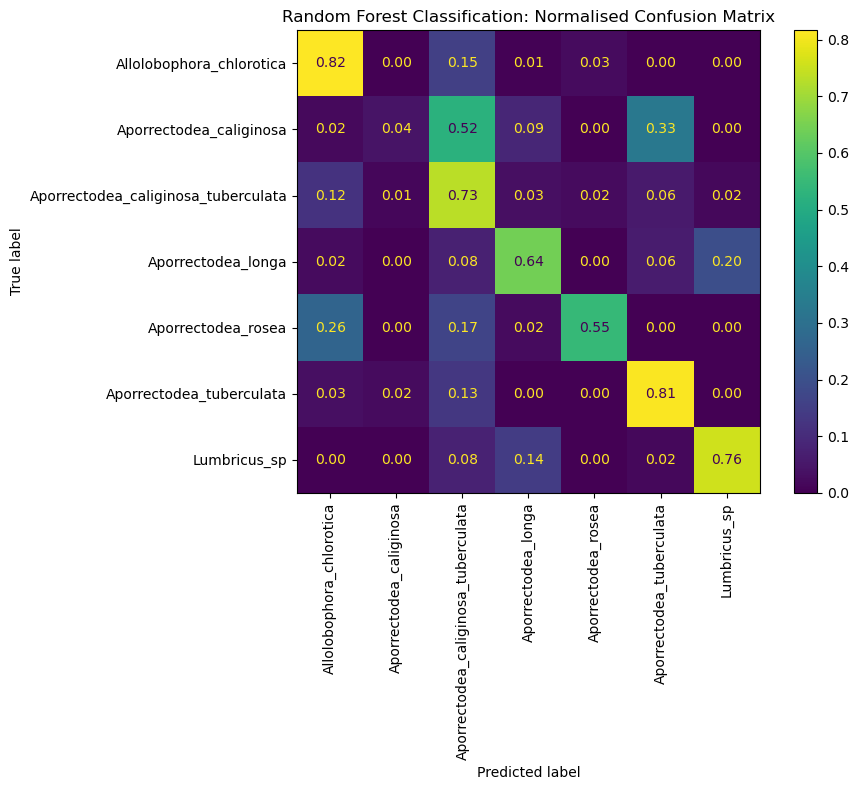

In [7]:
# -----------------------------
# 8. CONFUSION MATRIX
# -----------------------------

labels = sorted(np.unique(np.concatenate([y_test, y_pred])))

cm = confusion_matrix(y_test, y_pred, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=90, values_format=".2f")
plt.title("Random Forest Classification: Normalised Confusion Matrix")
plt.tight_layout()
plt.show()

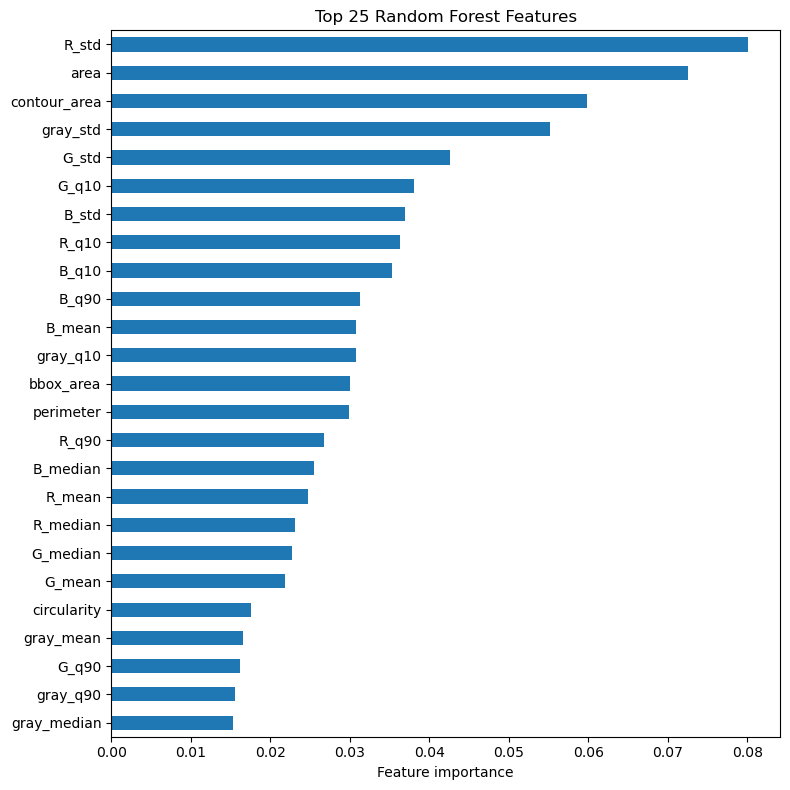

R_std            0.080088
area             0.072563
contour_area     0.059845
gray_std         0.055148
G_std            0.042595
G_q10            0.038044
B_std            0.036961
R_q10            0.036293
B_q10            0.035353
B_q90            0.031282
B_mean           0.030787
gray_q10         0.030777
bbox_area        0.030009
perimeter        0.029901
R_q90            0.026791
B_median         0.025428
R_mean           0.024779
R_median         0.023070
G_median         0.022682
G_mean           0.021863
circularity      0.017513
gray_mean        0.016513
G_q90            0.016161
gray_q90         0.015542
gray_median      0.015340
area_fraction    0.013893
major_axis       0.013690
hu_1             0.013367
minor_axis       0.012903
solidity         0.011689
dtype: float64


In [8]:
# -----------------------------
# 9. FEATURE IMPORTANCE
# -----------------------------

classifier = rf_model.named_steps["classifier"]

importance = pd.Series(
    classifier.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importance.head(25).sort_values().plot(kind="barh")
plt.xlabel("Feature importance")
plt.title("Top 25 Random Forest Features")
plt.tight_layout()
plt.show()

print(importance.head(30))

In [9]:
extra_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", ExtraTreesClassifier(
        n_estimators=800,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

extra_model.fit(X_train, y_train)

extra_pred = extra_model.predict(X_test)

print(classification_report(y_test, extra_pred))

                                     precision    recall  f1-score   support

           Allolobophora_chlorotica       0.69      0.83      0.75       196
            Aporrectodea_caliginosa       0.36      0.22      0.27        46
Aporrectodea_caliginosa_tuberculata       0.77      0.69      0.73       446
                 Aporrectodea_longa       0.66      0.71      0.69       132
                 Aporrectodea_rosea       0.56      0.57      0.56        42
           Aporrectodea_tuberculata       0.66      0.85      0.74       122
                       Lumbricus_sp       0.86      0.78      0.82       214

                           accuracy                           0.73      1198
                          macro avg       0.65      0.66      0.65      1198
                       weighted avg       0.73      0.73      0.72      1198

